# Notebook for preprocessing GFAS fire emission prior

In [1]:
import xarray as xr
import os
import numpy as np
import scipy.sparse as sp

import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs

# Examine the original data structure

In [2]:
DATA_PATH = "/home/pietaril/Documents/data/GFAS/original_GFAS_data/GFAS_CO2_2018.nc"
ds = xr.open_dataset(DATA_PATH)
ds["co2fire"]
#ds = ds.sortby(ds.latitude)


<xarray.DataArray 'co2fire' (valid_time: 365, latitude: 1800, longitude: 3600)>
[2365200000 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2018-01-01 2018-01-02 ... 2018-12-31
  * latitude    (latitude) float64 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * longitude   (longitude) float64 0.05 0.15 0.25 0.35 ... 359.8 359.9 359.9
Attributes:
    GRIB_paramId:                             210080
    GRIB_dataType:                            ga
    GRIB_numberOfPoints:                      6480000
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avg
    GRIB_gridType:                            regular_ll
    GRIB_uvRelativeToGrid:                    0
    GRIB_NV:                                  0
    GRIB_Nx:                                  3600
    GRIB_Ny:                                  1800
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           co2fire
    GRIB_gridDefinitionDescription:           Latitude/Longitude Grid
    GRIB_iDirectionIncrementInDegrees:        0.1
    GRIB_iScansNegatively:                    0
    GRIB_jDirectionIncrementInDegrees:        0.1
    GRIB_jPointsAreConsecutive:               0
    GRIB_jScansPositively:                    0
    GRIB_latitudeOfFirstGridPointInDegrees:   89.95
    GRIB_latitudeOfLastGridPointInDegrees:    -89.95
    GRIB_longitudeOfFirstGridPointInDegrees:  0.05
    GRIB_longitudeOfLastGridPointInDegrees:   359.95
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Wildfire flux of Carbon Dioxide
    GRIB_shortName:                           co2fire
    GRIB_totalNumber:                         0
    GRIB_units:                               kg m**-2 s**-1
    long_name:                                Wildfire flux of Carbon Dioxide
    units:                                    kg m**-2 s**-1
    standard_name:                            unknown
    GRIB_number:                              0
    GRIB_surface:                             0.0

In [5]:
ds["co2fire"] *= 3600

In [ ]:



# Save to new NetCDF
ds.to_netcdf('/home/pietaril/Documents/data/GFAS/test_sparse2.nc', encoding={'valid_time':{'units': "days since 1900-01-01"}, var_name: {'dtype': 'float64', 'zlib': True, 'complevel': 1}})#, 'chunksizes': (41, 200, 400)}})

print("Saved the modified dataset!")








# Helper functions to preprocess GFAS-type data

In [ ]:



def select_area(aoi, ds):
    # Determine the dimension names for latitude and longitude
    lat_name = 'lat' if 'lat' in ds.dims else 'latitude'
    lon_name = 'lon' if 'lon' in ds.dims else 'longitude'
    
    # Select the area based on the area of interest
    area_subset = ds.sel({lon_name: slice(aoi[0], aoi[1]),
                          lat_name: slice(aoi[2], aoi[3])})
    return area_subset


def preprocess_gfas(ds, aoi=None):
    """Preprocesses yearly GFAS data files to comply with CIF"""
    # order the latitude in ascending order (it's descending in the original)
    ds = ds.sortby(ds.latitude)
    ds.latitude.attrs.update({"stored_direction": "increasing"},)


    # convert longitudes from range 0-360 to -180, 180
    ds.coords['longitude'] = (ds.coords['longitude'] + 180) % 360 - 180
    ds = ds.sortby(ds.longitude)

    #select aoi
    if not aoi==None:
        ds = select_area(aoi, ds)

    #drop attributes copied from the initial dataset
    ds.attrs = {}
    ds.attrs.update({"description": "Preprocessed CO2 fire emissions from GFAS. Units and variable names changed from the original to comply with CIF",
                        "units": "kg(CO2) m-2 hr-1"})

    #rename variables to match CIF standard
    rename_map = {
        "valid_time" : "time",
        "co2fire": "emi_fire"
    }

    ds = ds.rename(rename_map)

    #convert to float64 
    ds["emi_fire"] = ds["emi_fire"].astype('float64')

    #convert units from kg/m2/s to kg/m2/hr
    ds["emi_fire"] *= 3600
    
    #update attributes
    ds.emi_fire.attrs = {}
    ds.emi_fire.attrs.update({"units": "kg(CO2) m-2 hr-1" })

    return ds



def write_to_file(dsout, OUT_PATH):
    # Save the result to a new NetCDF file
    year = dsout["time"].dt.year.values[0]
    # Write the output dataset to a new NetCDF file
    fname = f"compressed_fire_prior_GFAS_CO2_{year}.nc"
    dsout.to_netcdf(os.path.join(OUT_PATH,fname), encoding={'time':{'units': "days since 1900-01-01"}, "emi_fire": {'dtype': 'float64', 'zlib': True, 'shuffle':True, 'complevel': 5}})

    


## The actual preprocessing computed in LUMI on a separate script

In [3]:
DATA_PATH = "/home/pietaril/Documents/data/GFAS/original_GFAS_data/"
OUT_PATH = "/home/pietaril/Documents/data/GFAS/GFAS_CO2_emi_preprocessed/compressed/"
#aoi = [-12, 35, 35, 72]


fnames = [os.path.join(DATA_PATH,f) for f in os.listdir(DATA_PATH) if f.endswith(".nc")]
for fname in fnames:
    ds = xr.open_dataset(fname)
    out = preprocess_gfas(ds)
    write_to_file(out, OUT_PATH)
    ds.close()







: 

# Compare originals to compressed and not compressed files

In [3]:
NONCOMP = "/home/pietaril/Documents/data/GFAS/GFAS_CO2_2018_FROM_LUMI_NOT_COMPRESSED.nc"
COMP5 = "/home/pietaril/Documents/data/GFAS/GFAS_CO2_emi_preprocessed/complevel5/compressed_fire_prior_GFAS_CO2_2018.nc"
aoi = [-15, 35, 35, 72]

nds = xr.open_dataset(NONCOMP)
nds = select_area(aoi, nds)
nflux = nds["emi_fire"]

cds = xr.open_dataset(COMP5)
cds = select_area(aoi, cds)
cflux = cds["emi_fire"]

diff = nflux-cflux
diff

<xarray.DataArray 'emi_fire' (time: 365, latitude: 370, longitude: 500)>
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * time       (time) datetime64[ns] 2018-01-01 2018-01-02 ... 2018-12-31
  * latitude   (latitude) float64 35.05 35.15 35.25 35.35 ... 71.75 71.85 71.95
  * longitude  (longitude) float64 -14.95 -14.85 -14.75 ... 34.75 34.85 34.95

In [4]:
diff.values.min()

0.0

In [5]:
diff.values.max()

0.0

In [4]:
PATH_HIGHRES = "/home/pietaril/Documents/data/GFAS/GFAS_CO2_emi_preprocessed/fire_prior_GFAS_CO2_2018.nc"
PATH_COMP = "/home/pietaril/Documents/data/GFAS/GFAS_CO2_emi_preprocessed/compressed/compressed_fire_prior_GFAS_CO2_2018.nc"
aoi = [-15, 40, 35, 72]
varname = "emi_fire"

DATA_PATH = "/home/pietaril/Documents/data/GFAS/original_GFAS_data/GFAS_CO2_2018.nc"
ods = xr.open_dataset(DATA_PATH)
ods = ods.sortby("latitude")
ods.coords['longitude'] = (ods.coords['longitude'] + 180) % 360 - 180
ods = ods.sortby(ods.longitude)
ods = select_area(aoi, ods)
#rename variables to match CIF standard
rename_map = {
    "valid_time" : "time",
    "co2fire": "emi_fire"
    }

ods = ods.rename(rename_map)
#convert to same unit
ods[varname] = ods[varname]*3600

cds = xr.open_dataset(PATH_COMP)
cds = select_area(aoi, cds) 
#cds = cds[varname]

hds = xr.open_dataset(PATH_HIGHRES)
hds = select_area(aoi, hds)
#hds = hds[varname]



In [55]:
t = 250
diffh= ods[varname][t, :, :]-hds[varname][t,:,:]
diffc = ods[varname][t, :, :]-cds[varname][t,:,:]




In [58]:
diffh.values.min()

-1.9326762412674725e-11

In [59]:
diffc.values.min()

0.0

In [62]:
diffh.values.mean()

6.067022396347666e-16

In [ ]:
np.quantilediffh.values

AttributeError: 'numpy.ndarray' object has no attribute 'median'

In [60]:
diffh.values.max()

7.821654435247183e-11

In [61]:
diffc.values.max()

0.0

(array([     0.,      0.,      0.,      0.,      0., 203500.,      0.,
             0.,      0.,      0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5]),
 <BarContainer object of 10 artists>)

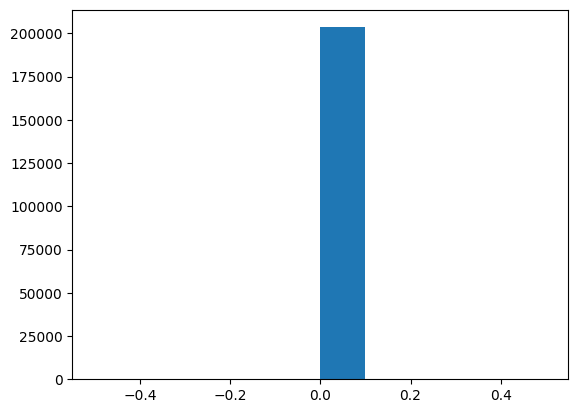

In [57]:
plt.hist(diffc.values.flatten())

In [54]:
np.finfo(np.float64).eps

2.220446049250313e-16

In [53]:
np.finfo(np.float32).eps

1.1920929e-07

# Conversion to g m-2 yr-1 for Tuulas plots

In [ ]:
def to_g_per_m2_per_yr(ds, var):
    """Helper function to convert daily fluxes with unit kg m-2 hr-1 to g m-2 yr-1"""
    time = ds["time"].values[0]
    #per hour to per day + kg to g
    out = ds[var]*24*1000
    #sum the daily values
    out = out.sum(dim="time")

    out = out.to_dataset()

    out.coords["time"] = (time) 
    out = out.expand_dims("time")
    return out

In [ ]:
var = "emi_fire"
otot = to_g_per_m2_per_yr(ods, var)
htot = to_g_per_m2_per_yr(hds, var)
ctot = to_g_per_m2_per_yr(cds, var)

In [46]:
hdiff = otot["emi_fire"]-htot["emi_fire"]

In [47]:
cdiff = otot["emi_fire"]-ctot["emi_fire"]

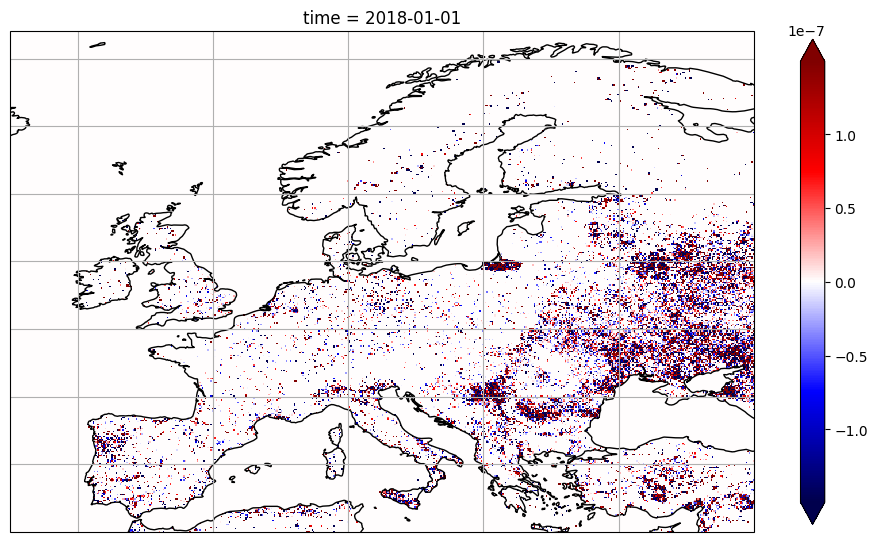

In [48]:
import matplotlib.pyplot as plt




cbar_label = ""#"emission [$g(CO_2)$ $m^{-2}$ $yr^{-1}$]"
variable = "emi_fire"
cbar_shrink = 0.7
from truncate_colormap import truncate_colormap
cmap = mpl.colormaps["seismic"] #truncate_colormap(mpl.colormaps["seismic"], minval=0.5)
#suptitle="Average yearly CO$_2$ fire emissions $2018-2022$"
datas = [otot, htot, ctot]



fig, ax = plt.subplots(figsize = (12,9), subplot_kw=dict(projection=ccrs.PlateCarree()))

#for i, ax in enumerate(axs):

hdiff[0].plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
ax.coastlines()
ax.gridlines()



(array([3.00000e+00, 1.00000e+00, 1.00000e+00, 4.00000e+00, 2.03456e+05,
        2.60000e+01, 4.00000e+00, 2.00000e+00, 2.00000e+00, 1.00000e+00]),
 array([-1.15411793e-03, -9.16151673e-04, -6.78185420e-04, -4.40219167e-04,
        -2.02252914e-04,  3.57133395e-05,  2.73679593e-04,  5.11645846e-04,
         7.49612099e-04,  9.87578352e-04,  1.22554461e-03]),
 <BarContainer object of 10 artists>)

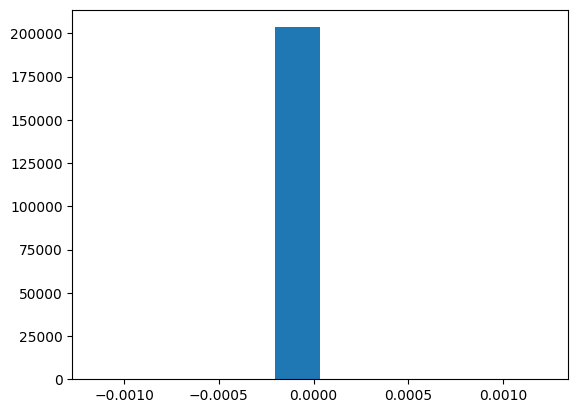

In [49]:
plt.hist(hdiff.values.flatten())

(array([1.0000e+00, 2.0000e+00, 2.0000e+00, 2.0000e+00, 1.2000e+01,
        2.0347e+05, 6.0000e+00, 2.0000e+00, 0.0000e+00, 3.0000e+00]),
 array([-1.18840951e-03, -9.67322756e-04, -7.46235996e-04, -5.25149237e-04,
        -3.04062478e-04, -8.29757191e-05,  1.38111040e-04,  3.59197799e-04,
         5.80284558e-04,  8.01371317e-04,  1.02245808e-03]),
 <BarContainer object of 10 artists>)

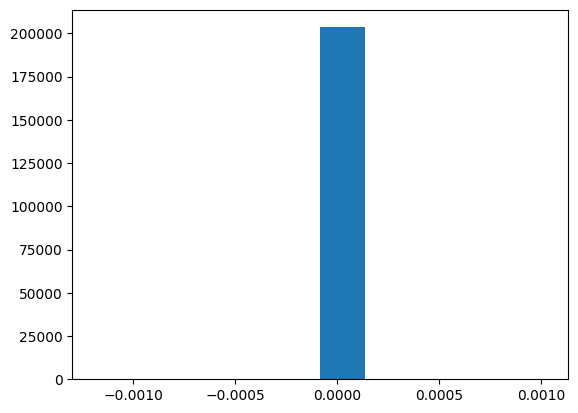

In [50]:
plt.hist(cdiff.values.flatten())

In [ ]:
PATH_COMP = "/home/pietaril/Documents/data/GFAS/GFAS_CO2_emi_preprocessed/compressed/compressed_fire_prior_GFAS_CO2_2018.nc"
aoi = [-15, 40, 35, 72]
varname = "emi_fire"

fnames = [os.path.join(PATH_COMP, f) for f in os.listdir(PATH_COMP)]
datasets = []
for fname in fnames:
    ds = xr.open_dataset(fname)
    eur = 
    yearly = to_g_per_m2_per_yr(ds, varname)
    datasets.append(yearly)


ds_allyears = xr.concat(datasets, dim="time") 
ds_allyears = ds_allyears.sortby("time")
ds_allyears


SyntaxError: invalid syntax (872188719.py, line 9)

# Compute total Finlands total yearly emission 

In [ ]:

from areagrid import areagrid

def g_per_m2_per_yr_to_Mt_per_yr(ds, var):
    
    lat = ds["latitude"].values
    lon = ds["longitude"].values


    # compute the areas of the gridcells in the data
    grid_of_areas = areagrid(lat, lon)

    # pointwise multiplication by area
    totals = ds[var] * grid_of_areas


    domain_tot = totals.sum(dim=("latitude", "longitude"))

    #g to Mt
    domain_tot = domain_tot*1e-12

    return domain_tot


def get_fin_mask(data_to_be_masked):

    """Helper function to get Finland mask with the same dimensionality
    as the data to be masked (when the data has the aoi used in this function."""

    MASK_PATH = "/home/pietaril/Documents/data/masks/country_masks/eez_01x01.nc4"
    ds_mask = xr.open_dataset(MASK_PATH)
    msk = ds_mask.Band1
    ds_mask.close()

    #limit the mask first to the same domain where the saved g/m2/yr values are
    latmin = data_to_be_masked["latitude"].values.min()-0.05
    latmax = data_to_be_masked["latitude"].values.max()+0.05
    lonmin = data_to_be_masked["longitude"].values.min()-0.05
    lonmax = data_to_be_masked["longitude"].values.max()+0.05
    aoi = [lonmin, lonmax, latmin, latmax]
    msk = select_area(aoi,msk)

    #Finland = 83
    msk_fin = msk==83

    #rename dimensions to match the ones in the data
    rename_map = {
        "lat": "latitude",
        "lon": "longitude",
        }
    msk_fin = msk_fin.rename(rename_map)

    #expand time dimension to match the data
    msk_fin_expanded = msk_fin.expand_dims(time=data_to_be_masked.time)

    return msk_fin_expanded

In [15]:
#expand the mask to match the dimensions of the data
msk_fin_expanded = get_fin_mask(ds_allyears)
fin_gm2yr = ds_allyears.where(msk_fin_expanded.values, drop=False)
fin_tot = g_per_m2_per_yr_to_Mt_per_yr(fin_gm2yr)



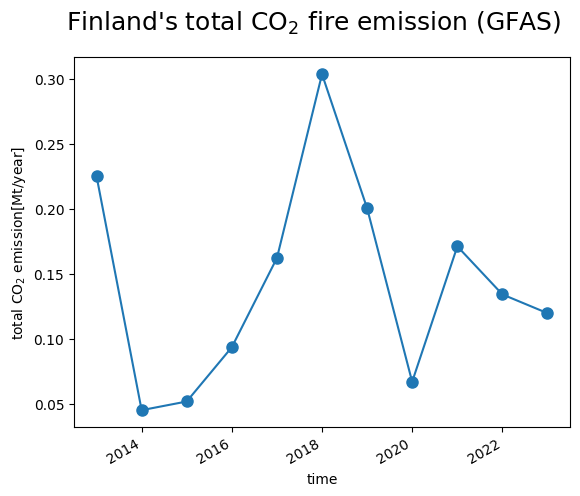

In [18]:

fig, ax = plt.subplots()

fin_tot.plot(x="time", ax=ax, marker='.', linestyle='solid', markersize=16)
ax.set_ylabel("total CO$_2$ emission[Mt/year]")
fig.suptitle("Finland's total CO$_2$ fire emission (GFAS)", fontsize = 18 )
plt.draw()
#figpath = "/home/pietaril/Documents/plots/EDGAR8/total_emis/"
figname = f"GFAS_yearly_totals_fin_CO2.png"

# Plotting functions

In [10]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    '''
    https://stackoverflow.com/a/18926541
    '''
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap



def plot_yearly_fluxes(ds, variable, ncols, cmap, cbar_label, suptitle=None):
    # Sample data from your dataset (replace 'ds_allyears' and 'emi_fire' with your data variables)
    data = ds[variable]

    # Define colorbar shrink parameter
    cbar_shrink = 0.8

    # Create the plot
    g = data.plot.pcolormesh(
        x="longitude",
        y="latitude",
        col="time",
        col_wrap=ncols,
        robust=True,
        aspect=1.25,
        cmap=cmap,
        subplot_kws=dict(projection=ccrs.PlateCarree()),
        cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink),
    )

    # Calculate the total number of subplots (including blanks)
    nplots = len(data.time)  # Total number of time slices
    nrows = (nplots + ncols - 1) // ncols  # Calculate number of rows (rounding up)

    # Adjust axes to handle blank spaces correctly
    for i, ax in enumerate(g.axes.flat):
        if i < nplots:  # Plot only for valid time slices
            time = str(data.time.values[i])[0:4]
            ax.set_title(time)
            ax.coastlines()
        else:  # Completely remove unused subplots
            g.fig.delaxes(ax)

    # Adjust the suptitle to account for the colorbar space
    # Compute the amount to shift the title leftward
    colorbar_offset = (1 - cbar_shrink) / 2  # Fraction of the figure width
    title_x_adjustment = colorbar_offset * g.fig.get_figwidth()

    # Add the suptitle and position it
    if not suptitle==None:
        g.fig.suptitle(
            suptitle,
            fontsize=18,
            x=0.5 - title_x_adjustment / g.fig.get_figwidth(),  # Centered and adjusted left
            y=0.9,  
        )

    # Adjust the spacing
    g.fig.subplots_adjust(top=0.85, right=0.8, wspace=0.1, hspace=0.15)

    # Draw the plot
    plt.draw()

In [11]:
#select Scandinavia

aoi_scand = [2, 31.5, 52.5, 72]

scand = select_area(aoi_scand, ds_allyears)

cbar_label = "emission [$g(CO_2)$ $m^{-2}$ $yr^{-1}$]"
variable = "emi_fire"
ncols = 4
cmap = truncate_colormap(mpl.colormaps["seismic"], minval=0.5)
suptitle="GFAS yearly CO$_2$ emissions"


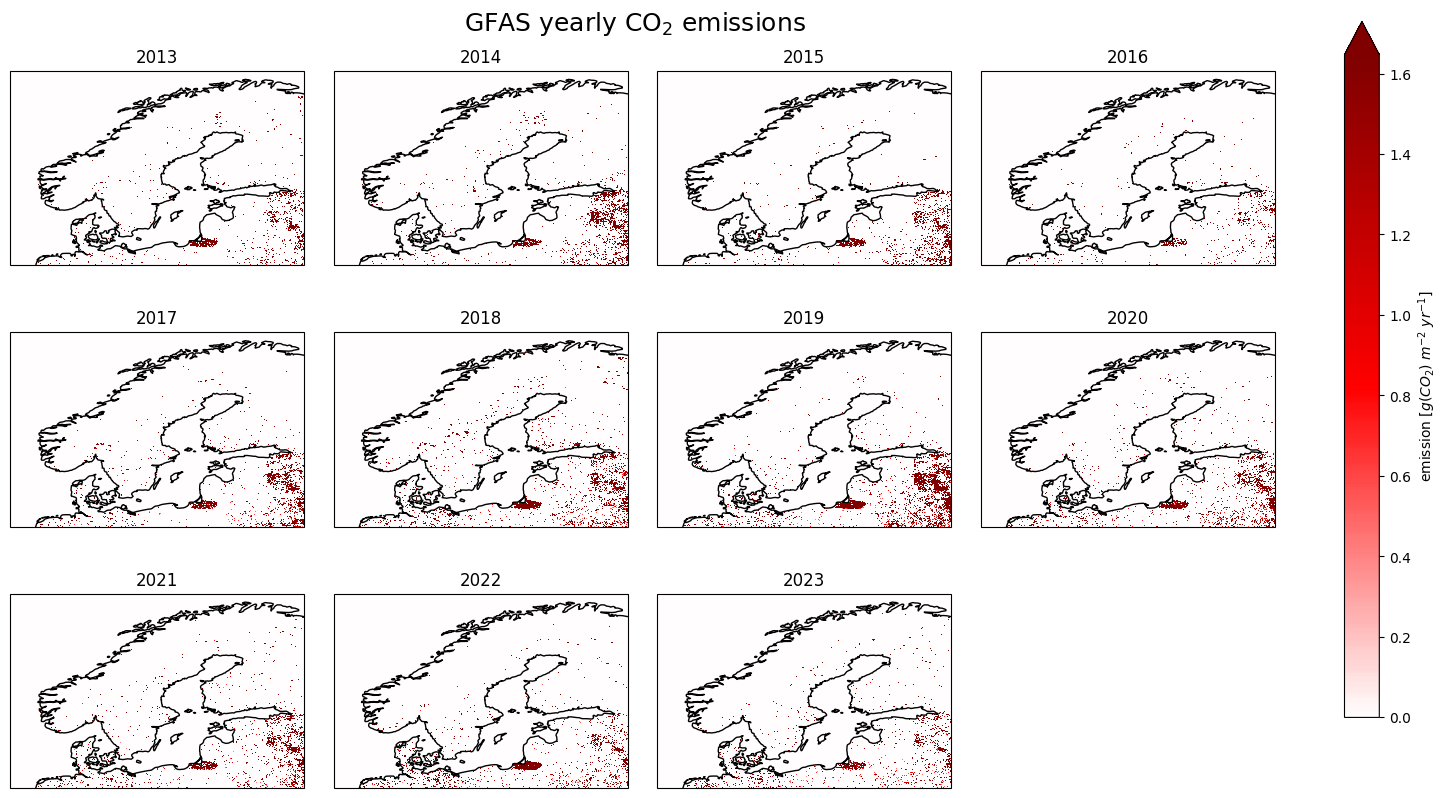

In [34]:
plot_yearly_fluxes(scand, "emi_fire", ncols, cmap, cbar_label, suptitle)

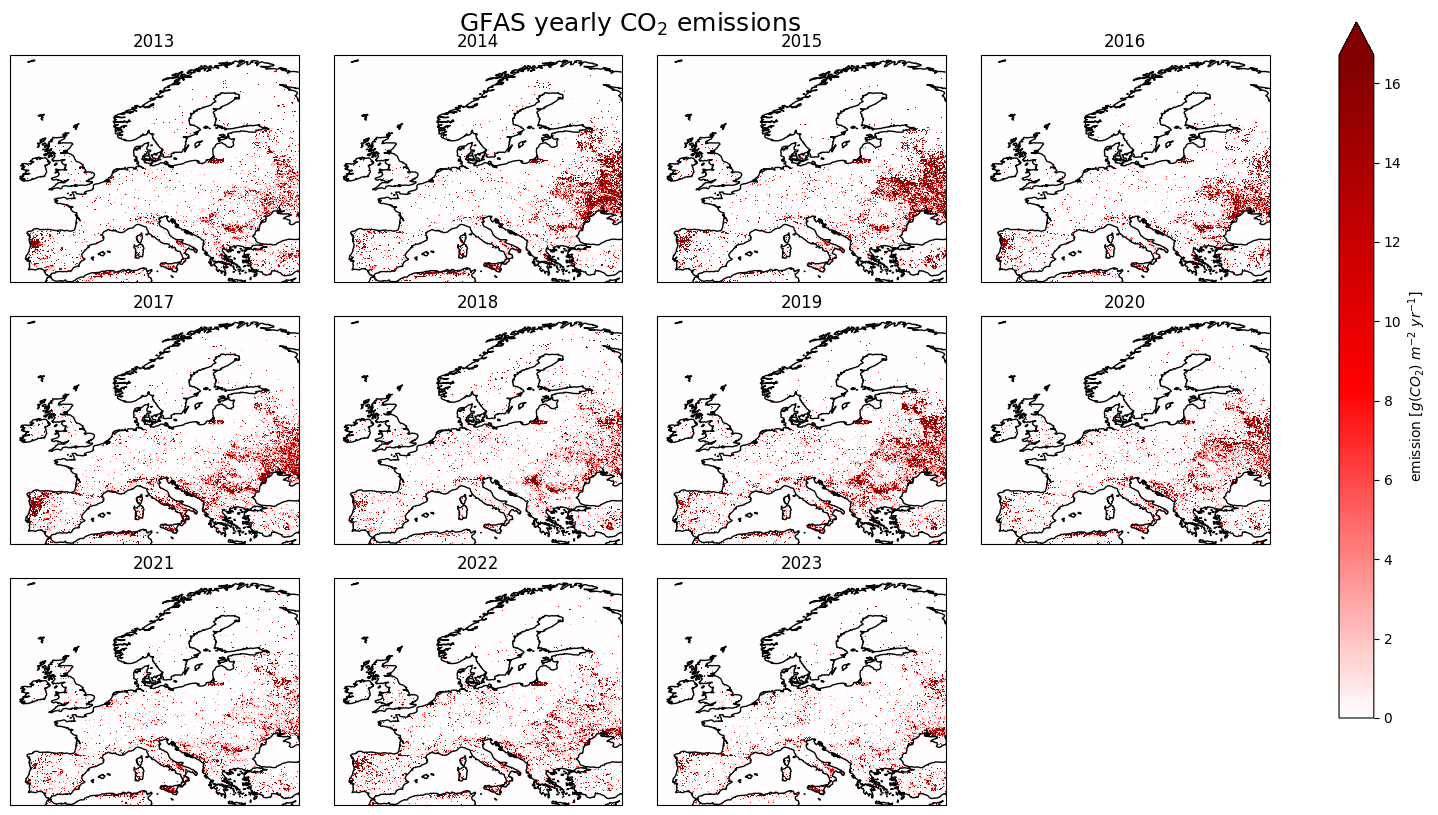

In [35]:
plot_yearly_fluxes(ds_allyears, variable, ncols, cmap, cbar_label, suptitle)
figpath = "/home/pietaril/Documents/plots/GFAS/"
figname = f"GFAS_yearly_CO2_emissions.png"
plt.savefig(figpath+figname)
plt.draw()

# Plot average for a range of years

In [13]:
#compute the mean for the chosen range of years
years = range(2018, 2023)

scand_18_22 = scand.isel(time=scand.time.dt.year.isin(years))
scand_ave = scand_18_22.mean(dim="time")
scand_ave


<xarray.Dataset>
Dimensions:    (latitude: 195, longitude: 295)
Coordinates:
  * latitude   (latitude) float64 52.55 52.65 52.75 52.85 ... 71.75 71.85 71.95
  * longitude  (longitude) float64 2.05 2.15 2.25 2.35 ... 31.25 31.35 31.45
Data variables:
    emi_fire   (latitude, longitude) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

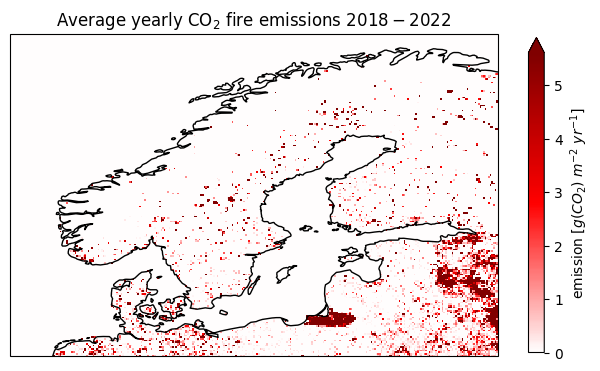

In [14]:
cbar_label = "emission [$g(CO_2)$ $m^{-2}$ $yr^{-1}$]"
variable = "emi_fire"
cbar_shrink = 0.7
cmap = truncate_colormap(mpl.colormaps["seismic"], minval=0.5)
suptitle="Average yearly CO$_2$ fire emissions $2018-2022$"




fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

scand_ave["emi_fire"].plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
ax.coastlines()
ax.set_title(suptitle)
plt.tight_layout()
plt.draw()
figpath = "/home/pietaril/Documents/plots/GFAS/"
figname = f"GFAS_scandinavia_mean_emis_2018_2022.png"
plt.savefig(figpath+figname)
plt.draw()

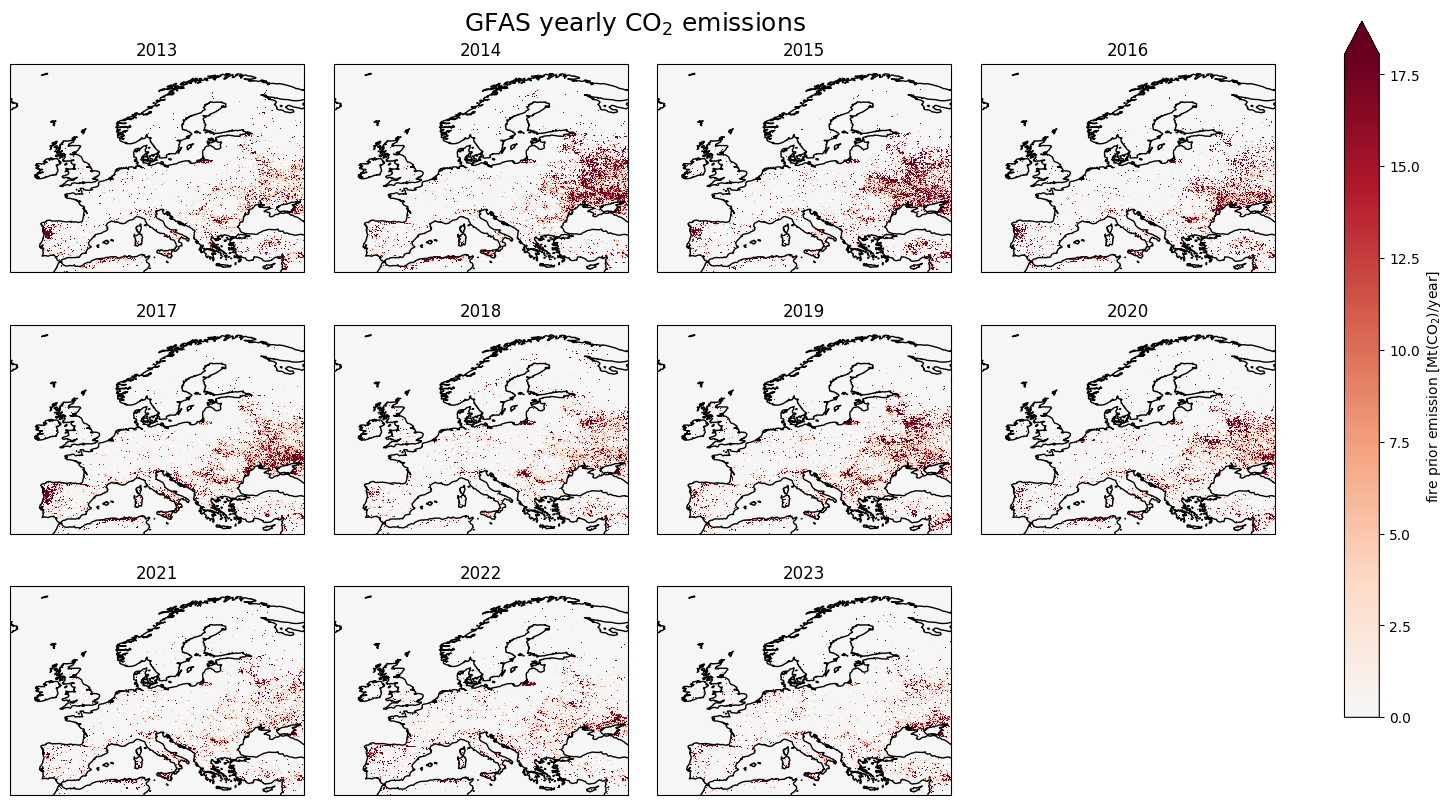

In [ ]:




ncols = 4  # Number of columns in the subplot grid
cmap = truncate_colormap(mpl.colormaps["RdBu_r"], minval=0.5)
# Sample data from your dataset (replace 'ds_allyears' and 'emi_fire' with your data variables)
data = ds_allyears["emi_fire"].sel()

# Define colorbar shrink parameter
cbar_shrink = 0.8

# Create the plot
g = data.plot.pcolormesh(
    x="longitude",
    y="latitude",
    col="time",
    col_wrap=ncols,
    robust=True,
    aspect=1.25,
    cmap=cmap,
    subplot_kws=dict(projection=ccrs.PlateCarree()),
    cbar_kwargs=dict(label="fire prior emission [Mt(CO$_2$)/year]", shrink=cbar_shrink),
)

# Calculate the total number of subplots (including blanks)
nplots = len(data.time)  # Total number of time slices
nrows = (nplots + ncols - 1) // ncols  # Calculate number of rows (rounding up)

# Adjust axes to handle blank spaces correctly
for i, ax in enumerate(g.axes.flat):
    if i < nplots:  # Plot only for valid time slices
        time = str(data.time.values[i])[0:4]
        ax.set_title(time)
        ax.coastlines()
    else:  # Completely remove unused subplots
        g.fig.delaxes(ax)

# Adjust the suptitle to account for the colorbar space
# Compute the amount to shift the title leftward
colorbar_offset = (1 - cbar_shrink) / 2  # Fraction of the figure width
title_x_adjustment = colorbar_offset * g.fig.get_figwidth()

# Add the suptitle and position it
g.fig.suptitle(
    "GFAS yearly CO$_2$ emissions",
    fontsize=18,
    x=0.5 - title_x_adjustment / g.fig.get_figwidth(),  # Centered and adjusted left
    y=0.9,  
)

# Adjust the spacing
g.fig.subplots_adjust(top=0.85, right=0.8, wspace=0.1, hspace=0.15)

# Draw the plot
plt.draw()

figpath = "/home/pietaril/Documents/plots/GFAS/"
figname = f"GFAS_yearly_CO2_emissions.png"
plt.savefig(figpath+figname)
plt.draw()

In [34]:



monthly_mean = ds.resample(time='M').mean()
monthly_max = ds.resample(time='M').max()


aug = ds.sel(time=slice("2018-08-01", "2018-08-31"))




In [31]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


def plot_fluxmaps(ds, figpath=None):
    data = ds["emi_fire"]
    g = data.plot.pcolormesh(x="longitude", y="latitude", col="time", col_wrap=4, robust=True, aspect=1.2,
                     subplot_kws=dict(projection=ccrs.PlateCarree()), cbar_kwargs = dict(label = "fire CO$_2$ prior flux [$kg$ $m^{-2} hr^{-1}$]", shrink=0.9 ),

    )


    for i, ax in enumerate(g.axes.flat):
        time = str(data.time.values[i])[0:7]
        ax.set_title(time)
        ax.coastlines()
        ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    plt.draw()

    if not figpath==None:
        figname = f"Fire_CO2_fluxmaps_{time[0:4]}.png"
        plt.savefig(figpath+figname)
        plt.draw()